# Test de Modelos de Clasificación de Imágenes

Este notebook permite probar cualquier modelo de clasificación de imágenes pre-entrenado. Carga imágenes de MinIO, muestra sus clases reales, hace predicciones y presenta los resultados de forma clara indicando aciertos (✓) y errores (✗).

In [1]:
import os
import sys
import io
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder

# Agregar src al path para importar las funciones del proyecto
sys.path.insert(0, os.path.abspath('..'))

from utils.funciones_minio import crear_cliente_minio, bajar_minio
from utils.config import CLASES_IMAGENES

print("✓ Librerías importadas correctamente")
print(f"✓ TensorFlow versión: {tf.__version__}")
print(f"✓ Clases disponibles: {CLASES_IMAGENES}")

✓ Librerías importadas correctamente
✓ TensorFlow versión: 2.21.0
✓ Clases disponibles: ['Cocina', 'Dormitorio', 'Salón', 'Banyo']


In [2]:
# ============================================
# CONFIGURACIÓN EDITABLE POR EL USUARIO
# ============================================

# Nombre del modelo a cargar (sin extensión .keras)
# NOTA: Modelos MLP requieren embeddings (512 dims), modelos CNN trabajan con imágenes
# Opciones CNN (imágenes): final_model, best_model
# Opciones MLP (embeddings): best_mlp_model, model-01-0.87, model-01-0.88, etc.
NOMBRE_MODELO = "best_mlp_model_cnn_base"

# Número de imágenes a cargar para la prueba (máximo: 12 para visualización óptima)
NUM_IMAGENES = 8

# Clase de la que cargar imágenes (opcional, None carga de todas)
CLASE_A_CARGAR = None  # Ej: "Cocina", "Dormitorio", "Salón", "Banyo"

# Rutas
RUTA_MODELO = f"../../{NOMBRE_MODELO}.keras"  # Relativa a este notebook
RUTA_MINIO_DATASET = "cleaned/dataset_vision"  # Ruta en MinIO donde están las imágenes

# Tamaño de imagen (debe coincidir con el modelo)
IMAGE_SIZE = (160, 240)

# ============================================
print(f"📁 Modelo a usar: {NOMBRE_MODELO}")
print(f"📊 Número de imágenes a cargar: {NUM_IMAGENES}")
print(f"🎨 Clases de imágenes: {CLASES_IMAGENES}")
print(f"\n💡 NOTA: El notebook detectará automáticamente si el modelo")
print(f"   requiere embeddings (MLP) o imágenes (CNN)")

📁 Modelo a usar: best_mlp_model_cnn_base
📊 Número de imágenes a cargar: 8
🎨 Clases de imágenes: ['Cocina', 'Dormitorio', 'Salón', 'Banyo']

💡 NOTA: El notebook detectará automáticamente si el modelo
   requiere embeddings (MLP) o imágenes (CNN)


In [3]:
def cargar_imagenes_de_minio(num_imagenes, clase_especifica=None):
    """
    Carga imágenes de MinIO de las clases especificadas.
    Usa el mismo método que analisis_cantidad_imagenes para consistencia.
    
    Args:
        num_imagenes (int): Cantidad de imágenes a cargar
        clase_especifica (str): Clase específica a cargar (None para todas)
    
    Returns:
        tuple: (lista de arrays de imagen, lista de clases, lista de IDs de registro)
    """
    from utils.funciones_minio import buscar_todos_los_archivos
    
    cliente = crear_cliente_minio()
    imagenes = []
    clases_cargadas = []
    ids_registros = []  # Para obtener embeddings después si es necesario
    
    # Determinar qué clases cargar
    clases_a_cargar = [clase_especifica] if clase_especifica else CLASES_IMAGENES
    
    imagenes_por_clase = max(1, num_imagenes // len(clases_a_cargar))
    
    print(f"🔄 Conectando a MinIO...")
    print(f"📥 Descargando imágenes de las clases: {clases_a_cargar}")
    print(f"📐 Redimensionando a: {IMAGE_SIZE}")
    
    for clase in clases_a_cargar:
        if len(imagenes) >= num_imagenes:
            break
        
        imagenes_cargadas_clase = 0
        
        try:
            # Obtener lista de archivos (parquets) de esta clase
            objetos = buscar_todos_los_archivos(cliente, f"{RUTA_MINIO_DATASET}/{clase}")
            
            if not objetos:
                print(f"  ⚠️ No se encontraron archivos para {clase}")
                continue
            
            # Iterar sobre cada archivo parquet de la clase
            for obj in objetos:
                if len(imagenes) >= num_imagenes:
                    break
                
                try:
                    # Descargar el parquet
                    df = bajar_minio(cliente, f"{RUTA_MINIO_DATASET}/{clase}", obj)
                    
                    # Iterar sobre las filas del dataframe
                    for idx, row in df.iterrows():
                        if len(imagenes) >= num_imagenes:
                            break
                        
                        try:
                            # Extraer bytes de imagen
                            imagen_bytes = row['imagen_bytes']
                            
                            # Convertir bytes a imagen PIL - ASEGURAR RGB
                            img = Image.open(io.BytesIO(imagen_bytes)).convert('RGB')
                            
                            # Redimensionar (width, height)
                            img = img.resize((IMAGE_SIZE[1], IMAGE_SIZE[0]))
                            
                            # Convertir a array, normalizar y asegurar 3 canales
                            img_array = np.array(img, dtype=np.float32) / 255.0
                            
                            # Validar forma
                            if img_array.shape != (IMAGE_SIZE[0], IMAGE_SIZE[1], 3):
                                print(f"  ⚠️ Forma inesperada: {img_array.shape}, esperado: {(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)}")
                                # Si no tiene 3 canales, intentar convertir
                                if len(img_array.shape) == 2:
                                    img_array = np.stack([img_array] * 3, axis=-1)
                                continue
                            
                            imagenes.append(img_array)
                            clases_cargadas.append(clase)
                            # Guardar el ID si existe (para buscar embeddings después)
                            if 'id' in row:
                                ids_registros.append(row['id'])
                            imagenes_cargadas_clase += 1
                            
                        except Exception as e:
                            continue
                    
                except Exception as e:
                    print(f"  ⚠️ Error cargando {obj}: {str(e)[:50]}")
                    continue
            
            if imagenes_cargadas_clase > 0:
                print(f"  ✓ Cargadas {imagenes_cargadas_clase} imágenes de {clase}")
            
        except Exception as e:
            print(f"  ❌ Error al procesar clase {clase}: {str(e)[:100]}")
            continue
    
    if not imagenes:
        raise ValueError("❌ No se pudieron cargar imágenes de MinIO. Verifica tu conexión y configuración.")
    
    print(f"\n✅ Total de imágenes cargadas: {len(imagenes)}")
    print(f"   Forma de cada imagen: {imagenes[0].shape}")
    return imagenes, clases_cargadas, ids_registros


# Ejecutar carga
imagenes_cargadas, clases_verdaderas, ids_registros = cargar_imagenes_de_minio(NUM_IMAGENES, CLASE_A_CARGAR)

🔄 Conectando a MinIO...
📥 Descargando imágenes de las clases: ['Cocina', 'Dormitorio', 'Salón', 'Banyo']
📐 Redimensionando a: (160, 240)
  ✓ Cargadas 8 imágenes de Cocina

✅ Total de imágenes cargadas: 8
   Forma de cada imagen: (160, 240, 3)


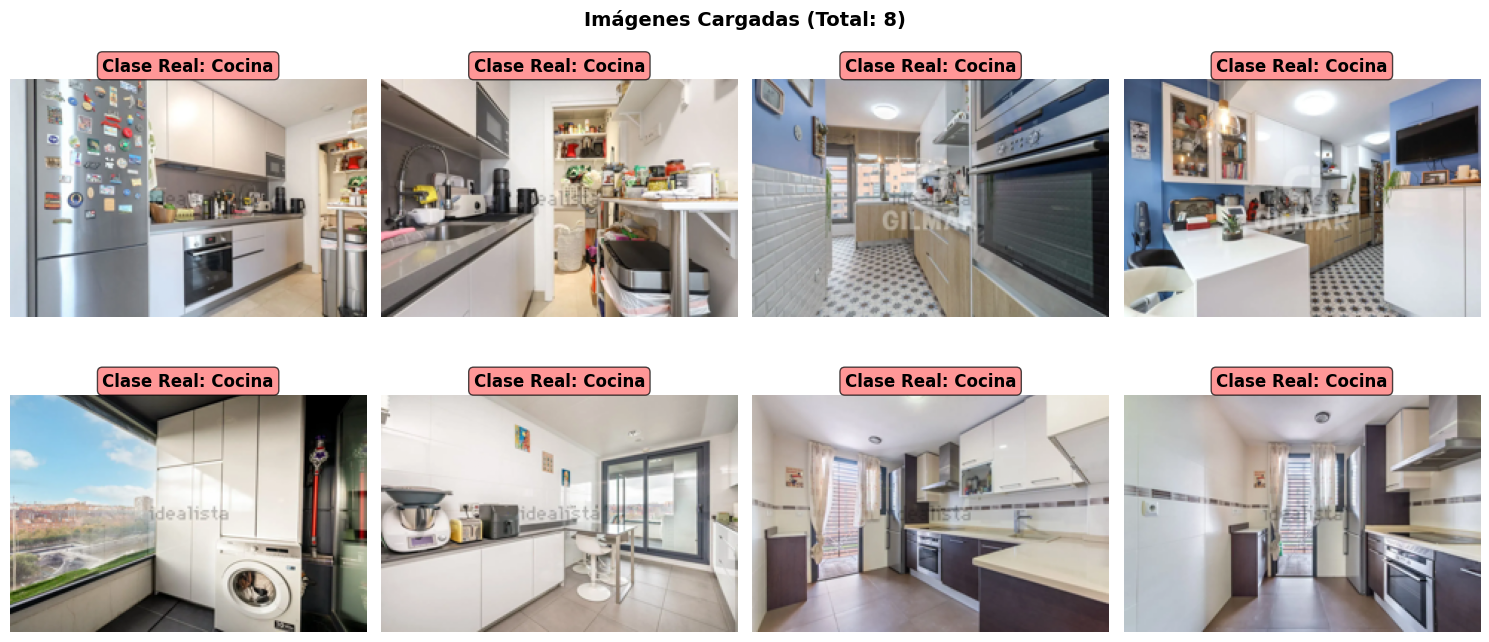

✓ Distribución de clases:
  - Cocina: 8 imágenes


In [5]:
# Guardar copia de imágenes originales para visualización posterior
imagenes_originales = imagenes_cargadas.copy()

# Mostrar imágenes cargadas con sus etiquetas reales
num_cols = min(4, len(imagenes_originales))
num_rows = (len(imagenes_originales) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3.5))
axes = axes.flatten() if len(imagenes_originales) > 1 else np.array([axes])

colores_clase = {
    'Cocina': '#FF6B6B',      # Rojo
    'Dormitorio': '#4ECDC4',  # Turquesa
    'Salón': '#45B7D1',       # Azul
    'Banyo': '#FFA07A'        # Salmón
}

for idx, (img, clase) in enumerate(zip(imagenes_originales, clases_verdaderas)):
    ax = axes[idx]
    
    # Mostrar imagen
    ax.imshow(img)
    
    # Configurar título con clase verdadera
    color = colores_clase.get(clase, '#CCCCCC')
    ax.set_title(f"Clase Real: {clase}", fontsize=12, fontweight='bold', 
                 bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
    
    ax.axis('off')

# Ocultar ejes sobrantes
for idx in range(len(imagenes_originales), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle(f"Imágenes Cargadas (Total: {len(imagenes_originales)})", 
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

print(f"✓ Distribución de clases:")
for clase in CLASES_IMAGENES:
    count = sum(1 for c in clases_verdaderas if c == clase)
    if count > 0:
        print(f"  - {clase}: {count} imágenes")

In [6]:
# Cargar el modelo
print(f"🤖 Intentando cargar modelo: {NOMBRE_MODELO}...")

try:
    # Navegar a la carpeta raíz del proyecto para encontrar el modelo
    ruta_modelo_absoluta = os.path.join(
        os.path.dirname(os.path.abspath('.')), 
        '..', 
        f'{NOMBRE_MODELO}.keras'
    )
    
    # Alternativa: buscar en la carpeta raíz
    if not os.path.exists(ruta_modelo_absoluta):
        ruta_modelo_absoluta = f"{NOMBRE_MODELO}.keras"
    
    if not os.path.exists(ruta_modelo_absoluta):
        # Buscar en el directorio actual
        ruta_modelo_absoluta = os.path.join(os.getcwd(), f"{NOMBRE_MODELO}.keras")
    
    print(f"  Buscando en: {ruta_modelo_absoluta}")
    
    if not os.path.exists(ruta_modelo_absoluta):
        print(f"  ❌ Modelo no encontrado en {ruta_modelo_absoluta}")
        print(f"  Archivos disponibles en el directorio actual:")
        for f in os.listdir('.')[:5]:
            print(f"    - {f}")
        raise FileNotFoundError(f"Modelo {NOMBRE_MODELO}.keras no encontrado")
    
    modelo = tf.keras.models.load_model(ruta_modelo_absoluta)
    print(f"✅ Modelo cargado exitosamente desde: {ruta_modelo_absoluta}")
    print(f"   Arquitectura:")
    modelo.summary()
    
except Exception as e:
    print(f"❌ Error al cargar el modelo: {str(e)}")
    raise

🤖 Intentando cargar modelo: best_mlp_model_cnn_base...
  Buscando en: best_mlp_model_cnn_base.keras
✅ Modelo cargado exitosamente desde: best_mlp_model_cnn_base.keras
   Arquitectura:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,172,878 (12.10 MB)

 Trainable params: 1,056,260 (4.03 MB)

 Non-trainable params: 4,096 (16.00 KB)

 Optimizer params: 2,112,522 (8.06 MB)

In [7]:
# (⚠️ OPCIONAL) Cargar embeddings para modelos MLP
# Ejecuta esta celda solo si vas a usar un modelo que requiere embeddings (512 dims)

print("📥 Cargando embeddings precompilados...")

from utils.config import MINIO_EMBEDDINGS

cliente = crear_cliente_minio()
df_embeddings = bajar_minio(cliente, MINIO_EMBEDDINGS, "embeddings_imagenes.parquet")

# Filtrar embeddings para las clases cargadas
df_embeddings_para_prediccion = df_embeddings[df_embeddings['clase'].isin(clases_verdaderas)].copy()

print(f"✅ Embeddings cargados: {len(df_embeddings_para_prediccion)} registros")
print(f"   Formas disponibles: {df_embeddings_para_prediccion['embedding'].iloc[0].shape if len(df_embeddings_para_prediccion) > 0 else 'N/A'}")
print(f"   Clases: {df_embeddings_para_prediccion['clase'].unique()}")

# Variable de control: marca que embeddings están listos
usar_embeddings = True
print(f"\n✓ EMBEDDINGS LISTOS para usar en predicciones: usar_embeddings = True")

📥 Cargando embeddings precompilados...
✅ Embeddings cargados: 37208 registros
   Formas disponibles: (2048,)
   Clases: <ArrowStringArray>
['Cocina']
Length: 1, dtype: str

✓ EMBEDDINGS LISTOS para usar en predicciones: usar_embeddings = True


## (Opcional) Cargar Embeddings para Modelos MLP

Ejecuta esta celda **SOLO si vas a usar un modelo MLP** (que requiere embeddings).
Si usas un modelo CNN, puedes saltarte esta celda.

In [8]:
print("🔍 Analizando modelo y preparando datos...")

# Obtener forma esperada del modelo
modelo_input_shape = modelo.input_shape
print(f"\n📊 Forma esperada por modelo: {modelo_input_shape}")

# PRIORIDAD 1: Si el usuario ejecutó la celda de embeddings, usar esos directamente
try:
    if usar_embeddings:
        print(f"\n✅ USANDO EMBEDDINGS (cargados en la celda anterior)")
        
        # Usar los embeddings ya cargados
        datos_prediccion = []
        imagenes_usadas = []
        clases_verificadas = []
        
        df_emb_temp = df_embeddings_para_prediccion.copy()
        
        for i, clase in enumerate(clases_verdaderas):
            # Obtener un embedding de esta clase
            emb = df_emb_temp[df_emb_temp['clase'] == clase]['embedding'].values
            
            if len(emb) > 0:
                # Tomar el primer embedding de esa clase
                datos_prediccion.append(emb[0])
                imagenes_usadas.append(imagenes_cargadas[i])
                clases_verificadas.append(clase)
                # Remover este registro para no repetirlo
                df_emb_temp = df_emb_temp.drop(
                    df_emb_temp[df_emb_temp['clase'] == clase].index[0]
                )
        
        imagenes_batch = np.array(datos_prediccion)
        imagenes_cargadas = imagenes_usadas
        clases_verdaderas = clases_verificadas
        print(f"   ✓ {len(imagenes_batch)} embeddings preparados para predicción")

except NameError:
    # PRIORIDAD 2: Si no hay embeddings cargados, detectar automáticamente por forma del modelo
    print(f"\n⚠️ Variable de embeddings no definida. Detectando automáticamente...")
    
    if modelo_input_shape[1] == 512:
        # El modelo espera embeddings pero no los tenemos cargados
        print(f"\n  ❌ ERROR: El modelo espera embeddings (512 dimensiones)")
        print(f"  📌 Por favor, ejecuta la celda anterior '(Opcional) Cargar Embeddings para Modelos MLP'")
        print(f"     para cargar los embeddings necesarios para este modelo MLP")
        raise ValueError("Embeddings requeridos pero no cargados")
    
    elif modelo_input_shape[1:] == (160, 240, 3):
        # El modelo trabaja directamente con imágenes CNN
        print(f"✅ Modelo CNN detectado - usando imágenes directas")
        imagenes_batch = np.array(imagenes_cargadas)
    
    else:
        # Forma desconocida
        print(f"⚠️ Forma de entrada no reconocida: {modelo_input_shape}")
        print(f"  Intentando usar las imágenes cargadas como están...")
        imagenes_batch = np.array(imagenes_cargadas)

print(f"\n  Forma final para predicción: {imagenes_batch.shape}")

# Hacer predicciones
print("\n🔍 Realizando predicciones...")
predicciones = modelo.predict(imagenes_batch, verbose=0)

# Procesar resultados
resultados = []
aciertos = 0

for idx, (clase_verdadera, prediccion) in enumerate(zip(clases_verdaderas, predicciones)):
    clase_predicha_idx = np.argmax(prediccion)
    clase_predicha = CLASES_IMAGENES[clase_predicha_idx]
    confianza = prediccion[clase_predicha_idx]
    
    es_correcto = clase_verdadera == clase_predicha
    if es_correcto:
        aciertos += 1
    
    # Obtener probabilidades para todas las clases
    probabilidades = {CLASES_IMAGENES[i]: float(prediccion[i]) for i in range(len(CLASES_IMAGENES))}
    
    resultados.append({
        'indice': idx,
        'clase_verdadera': clase_verdadera,
        'clase_predicha': clase_predicha,
        'confianza': confianza,
        'es_correcto': es_correcto,
        'probabilidades': probabilidades
    })

# Calcular accuracy
accuracy = aciertos / len(resultados) * 100

print(f"\n✅ Predicciones completadas!")
print(f"📊 Accuracy: {aciertos}/{len(resultados)} ({accuracy:.1f}%)")

🔍 Analizando modelo y preparando datos...

📊 Forma esperada por modelo: (None, 512)

✅ USANDO EMBEDDINGS (cargados en la celda anterior)
   ✓ 8 embeddings preparados para predicción

  Forma final para predicción: (8, 2048)

🔍 Realizando predicciones...


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'batch_normalization' is incompatible with the layer: expected axis -1 of input shape to have value 512, but received input with shape (8, 2048)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(8, 2048), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [9]:
# Mostrar resultados con visualización clara de aciertos/errores
num_cols = min(4, len(resultados))
num_rows = (len(resultados) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 4))
axes = axes.flatten() if len(resultados) > 1 else np.array([axes])

for idx, resultado in enumerate(resultados):
    ax = axes[idx]
    img = imagenes_originales[resultado['indice']]
    
    # Mostrar imagen
    ax.imshow(img)
    ax.axis('off')
    
    # Determinamos color según acierto/error
    es_correcto = resultado['es_correcto']
    
    if es_correcto:
        estado = "✓ CORRECTO"
        color_fondo = '#90EE90'  # Verde claro
        color_texto = 'darkgreen'
        borde_color = 'green'
        grosor_borde = 4
    else:
        estado = "✗ ERROR"
        color_fondo = '#FFB6C6'  # Rojo claro
        color_texto = 'darkred'
        borde_color = 'red'
        grosor_borde = 4
    
    # Agregar borde de color (acierto/error)
    for spine in ax.spines.values():
        spine.set_edgecolor(borde_color)
        spine.set_linewidth(grosor_borde)
        spine.set_visible(True)
    
    # Preparar texto del título
    titulo = (
        f"Clase Real: {resultado['clase_verdadera']}\n"
        f"Predicción: {resultado['clase_predicha']}\n"
        f"Confianza: {resultado['confianza']:.1%}\n"
        f"{estado}"
    )
    
    ax.set_title(titulo, fontsize=11, fontweight='bold', 
                 bbox=dict(boxstyle='round,pad=0.8', facecolor=color_fondo, 
                          edgecolor=borde_color, linewidth=2, alpha=0.95),
                 color=color_texto)

# Ocultar ejes sobrantes
for idx in range(len(resultados), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
titulo_general = f"Predicciones del Modelo: {NOMBRE_MODELO} | Accuracy: {aciertos}/{len(resultados)} ({accuracy:.1f}%)"
plt.suptitle(titulo_general, fontsize=14, fontweight='bold', y=0.998)
plt.show()

print("\n" + "="*60)
print(f"RESUMEN DE RESULTADOS")
print("="*60)
print(f"✅ Aciertos: {aciertos}")
print(f"❌ Errores: {len(resultados) - aciertos}")
print(f"📊 Accuracy: {accuracy:.1f}%")
print("="*60)

NameError: name 'resultados' is not defined

In [10]:
# Crear tabla de resultados
datos_tabla = []
for resultado in resultados:
    estado = "✓ CORRECTO" if resultado['es_correcto'] else "✗ ERROR"
    datos_tabla.append({
        'Imagen': resultado['indice'] + 1,
        'Clase Real': resultado['clase_verdadera'],
        'Clase Predicha': resultado['clase_predicha'],
        'Confianza': f"{resultado['confianza']:.2%}",
        'Resultado': estado
    })

df_resultados = pd.DataFrame(datos_tabla)

# Mostrar tabla
print("\n📋 TABLA DE RESULTADOS")
print("="*80)
print(df_resultados.to_string(index=False))
print("="*80)

# Estadísticas por clase
print("\n📊 ESTADÍSTICAS POR CLASE:")
print("-"*80)
for clase in CLASES_IMAGENES:
    aciertos_clase = sum(1 for r in resultados if r['clase_verdadera'] == clase and r['es_correcto'])
    total_clase = sum(1 for r in resultados if r['clase_verdadera'] == clase)
    
    if total_clase > 0:
        accuracy_clase = (aciertos_clase / total_clase) * 100
        print(f"  {clase:12} | Aciertos: {aciertos_clase:2}/{total_clase:2} | Accuracy: {accuracy_clase:6.1f}%")
    else:
        print(f"  {clase:12} | No hay muestras")

NameError: name 'resultados' is not defined

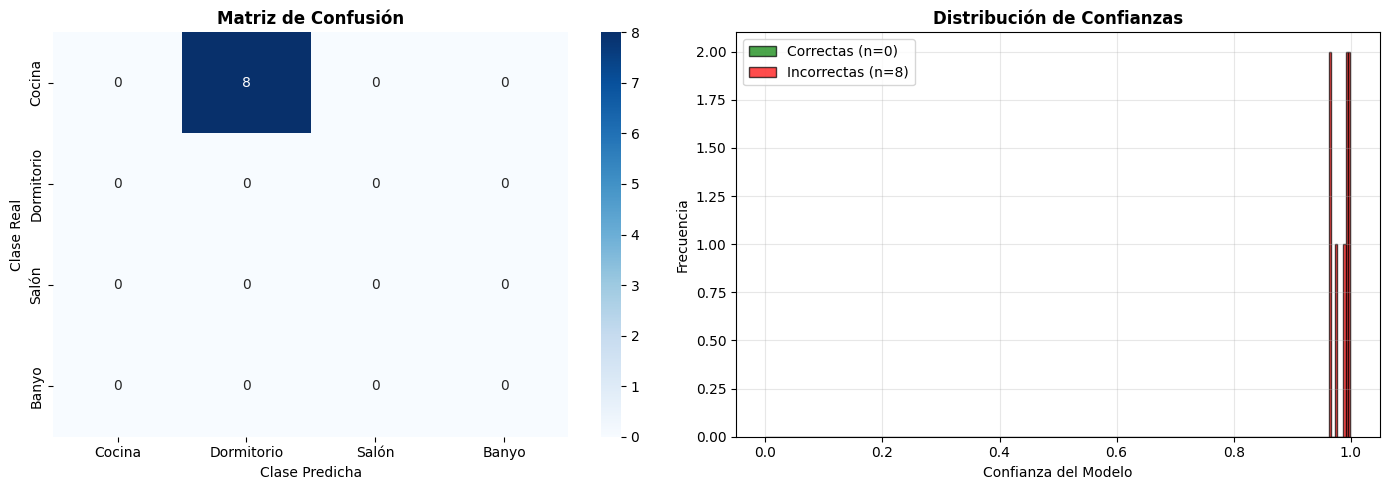


📈 ANÁLISIS DE CONFIANZA:
------------------------------------------------------------
Confianza promedio (Incorrectas): 98.37%
Confianza mín/máx (Incorrectas): 96.22% / 99.83%
------------------------------------------------------------


In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Crear matriz de confusión
clases_verdaderas_num = [CLASES_IMAGENES.index(r['clase_verdadera']) for r in resultados]
clases_predichas_num = [CLASES_IMAGENES.index(r['clase_predicha']) for r in resultados]

cm = confusion_matrix(clases_verdaderas_num, clases_predichas_num, 
                      labels=range(len(CLASES_IMAGENES)))

# Visualizar matriz de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax1,
            xticklabels=CLASES_IMAGENES, yticklabels=CLASES_IMAGENES)
ax1.set_title('Matriz de Confusión', fontsize=12, fontweight='bold')
ax1.set_xlabel('Clase Predicha')
ax1.set_ylabel('Clase Real')

# Distribución de confianzas
confianzas_correctas = [r['confianza'] for r in resultados if r['es_correcto']]
confianzas_incorrectas = [r['confianza'] for r in resultados if not r['es_correcto']]

ax2.hist(confianzas_correctas, bins=10, alpha=0.7, label=f'Correctas (n={len(confianzas_correctas)})', 
         color='green', edgecolor='black')
if confianzas_incorrectas:
    ax2.hist(confianzas_incorrectas, bins=10, alpha=0.7, label=f'Incorrectas (n={len(confianzas_incorrectas)})', 
             color='red', edgecolor='black')

ax2.set_xlabel('Confianza del Modelo')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Confianzas', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de confianza
print("\n📈 ANÁLISIS DE CONFIANZA:")
print("-"*60)
if confianzas_correctas:
    print(f"Confianza promedio (Correctas): {np.mean(confianzas_correctas):.2%}")
    print(f"Confianza mín/máx (Correctas): {np.min(confianzas_correctas):.2%} / {np.max(confianzas_correctas):.2%}")

if confianzas_incorrectas:
    print(f"Confianza promedio (Incorrectas): {np.mean(confianzas_incorrectas):.2%}")
    print(f"Confianza mín/máx (Incorrectas): {np.min(confianzas_incorrectas):.2%} / {np.max(confianzas_incorrectas):.2%}")
else:
    print("✅ ¡No hay predicciones incorrectas!")

print("-"*60)

## Estructura del Notebook

Este notebook está diseñado para ser **flexible y modular**:

1. **Celdas obligatorias**: 1, 2, 3, 4, 5, 6
2. **Celda opcional**: 5.5 "(Opcional) Cargar Embeddings para Modelos MLP"
3. **Celdas de análisis**: 7, 8, 9

## Instrucciones para Cambiar el Modelo

Para probar un diferente modelo, edita la **celda 3** y cambia la variable `NOMBRE_MODELO`:

```python
NOMBRE_MODELO = "final_model"  # Cambia esto
```

### ⚠️ Importante: Tipos de Modelos

**🖼️ Modelos CNN (Imágenes directas):**
- `final_model` ✓ Recomendado - **NO necesita ejecutar la celda de embeddings**
- `best_model` - **NO necesita ejecutar la celda de embeddings**

**🧠 Modelos MLP (Embeddings precompilados):**
- `best_mlp_model` - **DEBES ejecutar la celda de embeddings**
- `model-01-0.87`, `model-01-0.88` - **DEBES ejecutar la celda de embeddings**
- `model-02-0.88`, `model-02-0.89` - **DEBES ejecutar la celda de embeddings**
- `model-03-0.88`, `model-03-0.89` - **DEBES ejecutar la celda de embeddings**
- Y otros modelos numéricos... - **DEBES ejecutar la celda de embeddings**

### 📋 Flujo de Ejecución

#### Para Modelos CNN (ejemplo: `final_model`):
```
1. Importar librerías
2. Configuración parámetros
3. Cargar imágenes
4. Mostrar imágenes
5. Cargar modelo
6. ⏭️ SALTA la celda de embeddings (opcional)
7. Hacer predicciones
8-10. Ver resultados
```

#### Para Modelos MLP (ejemplo: `best_mlp_model`):
```
1. Importar librerías
2. Configuración parámetros
3. Cargar imágenes
4. Mostrar imágenes
5. Cargar modelo
6. ✅ EJECUTA la celda de embeddings (opcional)
7. Hacer predicciones
8-10. Ver resultados
```

### Parámetros Adicionales (Celda 3):

- **`NUM_IMAGENES`**: Cantidad de imágenes a probar (máx 12 para visualización óptima)
- **`CLASE_A_CARGAR`**: Para cargar imágenes de una sola clase (Ej: "Cocina", None para todas)

## 9. Matriz de Confusión y Análisis de Confianza

## 8. Tabla Detallada de Resultados

## 7. Mostrar Predicciones vs Clases Reales (Resultados Detallados)

## 6. Hacer Predicciones en todas las Imágenes

## 5. Cargar Modelo Pre-entrenado

## 4. Mostrar Imágenes con Clases Verdaderas

## 3. Cargar Imágenes desde MinIO

## 2. Configurar Parámetros (EDITA AQUÍ)

## 1. Importar Librerías Necesarias